# Churn Calibration (ECE) & Business Decision Layer

Calibrates the CatBoost churn classifier's probabilities (`03a_CatBoost_and_Cox_Models.ipynb`) and builds the retention priority score / business decision layer on top of it. Uses `kkbox.calibrate` and `kkbox.business` (ECE, isotonic regression, priority scoring, budget allocation, rank sensitivity) rather than redefining this logic inline.

In [1]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier

from kkbox.business import build_priority_scores, budget_allocation_comparison, five_segment_illustration, rank_sensitivity
from kkbox.calibrate import compute_ece, fit_isotonic, reliability_diagram
from kkbox.fwd_rev import load_fwd_rev_predictor

PROCESSED_DIR = os.path.join(os.getcwd(), "data", "processed")
MODELS_DIR = os.path.join(os.getcwd(), "models")
RESULTS_DIR = os.path.join(os.getcwd(), "results")

with open(os.path.join(PROCESSED_DIR, "feature_manifest.json")) as f:
    manifest = json.load(f)

CAT_COLS = [v["column"] for v in manifest["categorical"].values()]
NUM_COLS = manifest["numerical_scaled"] + manifest["numerical_unscaled"]
FEATURE_COLS = CAT_COLS + NUM_COLS

In [2]:
val_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_val.parquet"))
test_df = pd.read_parquet(os.path.join(PROCESSED_DIR, "model_dataset_test.parquet"))

churn_model = CatBoostClassifier()
churn_model.load_model(os.path.join(MODELS_DIR, "catboost_churn.cbm"))

val_probs_raw = churn_model.predict_proba(val_df[FEATURE_COLS])[:, 1]
test_probs_raw = churn_model.predict_proba(test_df[FEATURE_COLS])[:, 1]
val_true_np = val_df["is_churn"].values
test_true_np = test_df["is_churn"].values

# Forward-revenue model: whichever won the CatBoost-Tweedie-vs-ZILN comparison in
# 03c_ZILN_ForwardRevenue.ipynb (see results/fwd_rev_model_choice.json) - predict_fwd_rev
# already produces raw-TWD predictions, no log1p/expm1 round-trip needed either way.
predict_fwd_rev, fwd_rev_winner = load_fwd_rev_predictor(PROCESSED_DIR, MODELS_DIR, RESULTS_DIR, FEATURE_COLS)
val_fwd_rev_pred_raw = predict_fwd_rev(val_df)
test_fwd_rev_pred_raw = predict_fwd_rev(test_df)

print(f"forward-revenue model in production: {fwd_rev_winner}")
print(f"val: {len(val_df):,} rows, test: {len(test_df):,} rows")

forward-revenue model in production: catboost
val: 241,526 rows, test: 241,526 rows


## Section 7.2: Expected Calibration Error (ECE)

10 equal-width probability bins; `ECE = sum_b (|B_b| / N) * |avg_confidence(b) - avg_accuracy(b)|`. Fit on validation, report on the held-out test set.

In [3]:
ece_raw, bins_raw = compute_ece(test_probs_raw, test_true_np)
print(f"ECE, uncalibrated (test): {ece_raw:.4f}   (target: < 0.05 for a well-calibrated model)")
print(f"mean predicted P(churn)={test_probs_raw.mean():.4f} vs. true churn rate={test_true_np.mean():.4f}")
bins_raw

ECE, uncalibrated (test): 0.0043   (target: < 0.05 for a well-calibrated model)
mean predicted P(churn)=0.7360 vs. true churn rate=0.7360


,bin_lo,bin_hi,n,avg_confidence,avg_accuracy
0,0.0,0.1,36143,0.029490,0.022660
1,0.1,0.2,5470,0.141595,0.138757
2,0.2,0.3,4465,0.251665,0.265622
3,0.3,0.4,5152,0.351866,0.329387
4,0.4,0.5,5652,0.450294,0.433475
5,0.5,0.6,6007,0.550126,0.544531
6,0.6,0.7,7061,0.652792,0.651041
7,0.7,0.8,11993,0.753781,0.754190
8,0.8,0.9,20905,0.856346,0.857450
9,0.9,1.0,138678,0.977689,0.980747


CatBoost's raw probabilities are **already well-calibrated** — ECE=0.0043 is comfortably under the 0.05 "well-calibrated" bar, and mean predicted P(churn) (0.7360) is nearly identical to the true churn rate (0.7360). Most bins track the diagonal closely (e.g. [0.3, 0.4): 0.352 predicted vs. 0.329 observed); the largest deviations are a mild *overconfidence* in the near-zero bin ([0.0, 0.1): 0.029 predicted vs. 0.023 observed) and a mild *underconfidence* in the highest bin ([0.9, 1.0): 0.978 vs. 0.981, covering 57% of the test set). CatBoost's `Logloss` training here has no class-imbalance reweighting, so there's no systematic prior-shift to correct. Isotonic regression below still tightens ECE further, but it's polishing an already-good result rather than fixing a broken one.

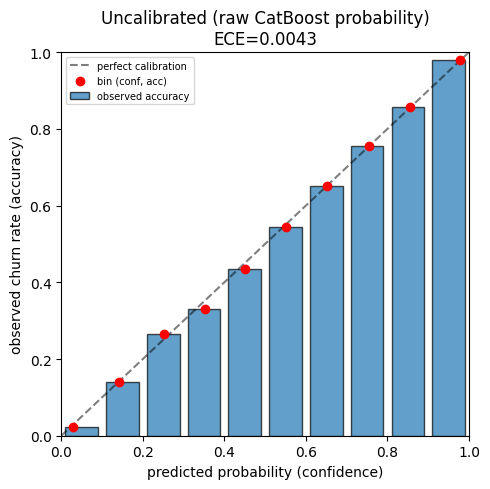

In [4]:
fig, ax = plt.subplots(figsize=(5, 5))
reliability_diagram(ax, bins_raw, ece_raw, "Uncalibrated (raw CatBoost probability)")
fig.tight_layout()

### Isotonic regression

Isotonic regression (a non-parametric monotone mapping, fit on validation predicted-probability → observed-outcome pairs) can correct arbitrary miscalibration shapes, including a systematic shift — unlike a single-scalar rescaling (e.g. temperature scaling), which can only adjust *sharpness*, not the overall level.

ECE after isotonic regression (test): 0.0018
mean predicted P(churn) after isotonic: 0.7363 vs. true rate 0.7360


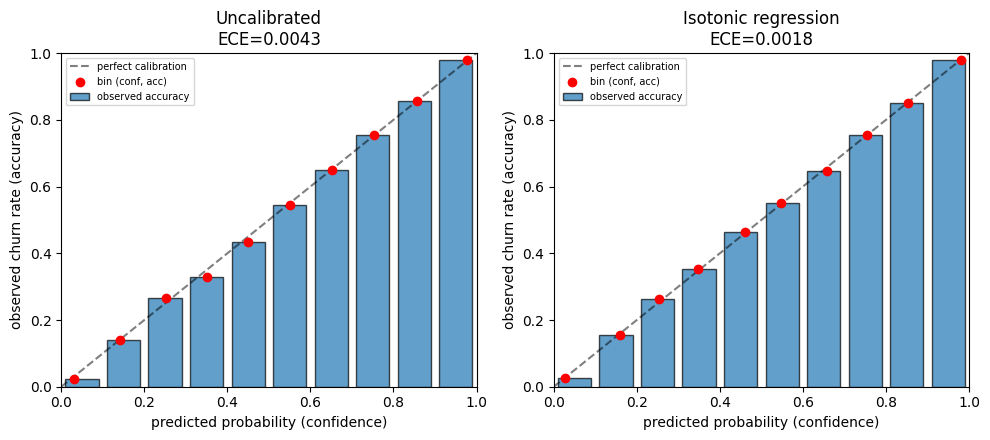

In [5]:
iso_reg = fit_isotonic(val_probs_raw, val_true_np)
test_probs_iso = iso_reg.predict(test_probs_raw)
ece_iso, bins_iso = compute_ece(test_probs_iso, test_true_np)
print(f"ECE after isotonic regression (test): {ece_iso:.4f}")
print(f"mean predicted P(churn) after isotonic: {test_probs_iso.mean():.4f} vs. true rate {test_true_np.mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
reliability_diagram(axes[0], bins_raw, ece_raw, "Uncalibrated")
reliability_diagram(axes[1], bins_iso, ece_iso, "Isotonic regression")
fig.tight_layout()

**Isotonic regression is the calibration method used going forward** (business layer below uses `iso_reg`-calibrated probabilities) — it took ECE from 0.0043 (already reasonably calibrated) to 0.0018. The AUC-based ranking is unaffected since it's a monotone transform of the same raw probabilities.

## Section 8: Business Decision Layer

`Retention Priority Score = P(churn)_percentile x E[forward revenue]` — expected revenue at risk per user. `E[forward revenue]` is the Tweedie-loss regressor's prediction directly in raw TWD (see `03a_CatBoost_and_Cox_Models.ipynb` — no `log1p`/`expm1` round-trip needed). This is the `fwd_rev_59d` target from `02_Feature_Engineering.ipynb` — the forward-looking 59-day revenue window (see `project_report.md` section 3.2), not a lifetime-value estimate — so "priority score" should be read as "near-term revenue at risk," which is if anything a more actionable framing for a monthly retention budget.

**Why `P(churn)_percentile` instead of the raw calibrated probability**: since the survivorship-bias fix, churn is the majority outcome (~74% of users), so most calibrated probabilities now cluster in a similarly high range — raw `P(churn)` no longer cleanly separates a small at-risk minority the way it did under the old ~9%-churn framing. Converting to each user's *percentile rank* of `P(churn)` within the test population restores a well-spread [0, 1] scale regardless of how compressed the underlying probability distribution is, so the priority score still meaningfully discriminates between users rather than being driven almost entirely by `E[forward revenue]` alone. `p_churn_raw` (the calibrated probability itself) is kept alongside for reference/display, but `p_churn` — used everywhere below — is the percentile-rank version.

In [6]:
results = build_priority_scores(
    msno=test_df["msno"].values,
    is_churn=test_true_np,
    p_churn_calibrated=test_probs_iso,
    fwd_rev_pred_raw=test_fwd_rev_pred_raw,
)
print(f"p_churn_raw range: [{results['p_churn_raw'].min():.4f}, {results['p_churn_raw'].max():.4f}], "
      f"{results['p_churn_raw'].nunique()} distinct values")
print(f"p_churn (percentile) range: [{results['p_churn'].min():.4f}, {results['p_churn'].max():.4f}], "
      f"{results['p_churn'].nunique()} distinct values")
results.head(10)

p_churn_raw range: [0.0000, 1.0000], 280 distinct values
p_churn (percentile) range: [0.0047, 0.9985], 280 distinct values


,msno,is_churn,p_churn_raw,e_fwd_rev,p_churn,priority_score,rank
0,1Z9JwsTOUwN0a8pacQndd8iZzYGrIOG+bOHO71yET1k=,0,0.254866,2669.933659,0.183411,489.694924,1
1,DTV8itASH4IWHDfDpKKNRYMWe+dZECbTyQD1vObJtiY=,1,0.447644,1914.252670,0.226181,432.966852,2
2,n4y82Ocxfa7CiYARWtOPfqweocvBkh9oerW0+z+Gy+4=,0,0.928265,881.970774,0.441410,389.310750,3
3,yzKJQs1BDs4u/T1/gzILJrmG7SmglNhfmkWpx+mefKI=,1,0.915254,803.928834,0.426507,342.881176,4
4,9EfX+Y5GtkOgGFXrndPX3wlMDUiF1+cQH6+mk3lnBT0=,1,0.957726,658.546928,0.493700,325.124928,5
5,QBH//eMZ6ey+kR5iU4U+mTEMJlBPVuMpJymYPrBr81o=,1,0.380015,1455.010405,0.217817,316.926190,6
6,WJaOAIQ/sk0uElD9e31oTQDgfOtc2rgWalIkWYuRoC0=,0,0.928265,647.433426,0.441410,285.783611,7
7,5phQpiVg80yLFxJSCTazb5XT6BEKhzxblPl7CArdXDY=,1,0.876433,726.944388,0.391417,284.538746,8
8,6/hyr4EkvkDWdx8BCkX6UMVSYCUAgckZ8qYMpA+M5yE=,1,0.915254,643.847781,0.426507,274.605506,9
9,Q2bdS046TSToczpQq66UQ2eOPAV7mQ9W98v/DUHC5h4=,0,0.912589,652.956987,0.415485,271.294023,10


### Five-segment illustration (Section 8.1)

Real test-set users picked to match each segment definition from the plan's table, using the 33rd/67th percentiles of `p_churn` and `e_fwd_rev` as the low/medium/high thresholds.

In [7]:
five_segment_illustration(results)

,segment,p_churn_percentile,p_churn_raw,e_fwd_rev_twd,priority_score,recommended_action
0,"high-risk, high-value",0.707133,0.989482,294.661808,208.365082,"Immediate: personal outreach, premium discount"
1,"high-risk, low-value",0.946248,0.998240,0.352332,0.333394,Low priority: automated email only
2,"low-risk, high-value",0.183411,0.254866,167.190763,30.664608,Monitor: no immediate action needed
3,"medium-risk, medium-value",0.397452,0.883257,143.269564,56.942780,Queue for weekly retention campaign
4,"low-risk, low-value",0.277401,0.674354,78.006919,21.639180,No action: below cost-of-retention threshold


### Budget allocation (Section 8.2)

Greedy allocation: rank all users by priority score, spend a fixed per-user voucher cost down the ranked list until the budget runs out. Compares the joint-model ranking against two naive strategies — random selection, and churn-probability-only ranking (ignoring forward revenue) — using the same expected-value formula for all three so the comparison isolates the *ranking strategy*, not the value formula.

**Coverage note, post bias-fix**: the budget size and per-voucher cost below are unchanged from the original plan — a real retention budget doesn't automatically scale just because the *measured* churn rate went from ~9% to ~74%. But the *coverage* story is very different now: this budget was always going to fund a small fraction of the test set, but it now funds an even smaller fraction of the population that's actually expected to churn (previously a small budget could meaningfully dent a small at-risk minority; now it reaches a sliver of a much larger at-risk majority). The ranking strategy matters more, not less, when the budget can only ever touch a fraction of a percent of who's actually at risk.

In [8]:
BUDGET_TWD = 50_000
VOUCHER_COST_TWD = 50
RETENTION_SUCCESS_RATE = 0.30  # assumed effectiveness of a retention offer, per plan's stated 20-40% range

budget = budget_allocation_comparison(results, BUDGET_TWD, VOUCHER_COST_TWD, RETENTION_SUCCESS_RATE)
n_interventions = budget["n_interventions"]

print(f"budget covers {budget['n_interventions']:,} interventions out of {budget['n_test_users']:,} test users "
      f"({budget['coverage_of_test_set_pct']:.2f}% of the test set)")
print(f"vs. {budget['n_actual_churners']:,} users who actually churn "
      f"({budget['coverage_of_at_risk_pct']:.2f}% of the true at-risk population)")
print(f"expected revenue saved, model ranking:        {budget['revenue_model_twd']:>12,.0f} TWD")
print(f"expected revenue saved, random selection:      {budget['revenue_random_twd']:>12,.0f} TWD "
      f"({budget['model_vs_random_pct']:+.1f}% vs. model)")
print(f"expected revenue saved, churn-prob-only rank:  {budget['revenue_churn_only_twd']:>12,.0f} TWD "
      f"({budget['model_vs_churn_only_pct']:+.1f}% vs. model)")

budget covers 1,000 interventions out of 241,526 test users (0.41% of the test set)
vs. 177,757 users who actually churn (0.56% of the true at-risk population)
expected revenue saved, model ranking:              65,567 TWD
expected revenue saved, random selection:            13,310 TWD (+392.6% vs. model)
expected revenue saved, churn-prob-only rank:            20 TWD (+320809.9% vs. model)


### Sensitivity analysis (Section 8.3)

Perturb `p_churn` by +/-10% and recompute the ranking: users whose rank barely moves are robustly prioritized (safe to act on); users with large rank swings are borderline and worth a second look before committing budget.

Among the top 1,000 budget-funded users:
  median rank_delta under +/-10% P(churn) perturbation: 0
  users with rank_delta > 1000 (could fall out of budget): 0 (0.0%)
  distinct p_churn_raw values among top 1,000: 23 (largest tie group: 903)


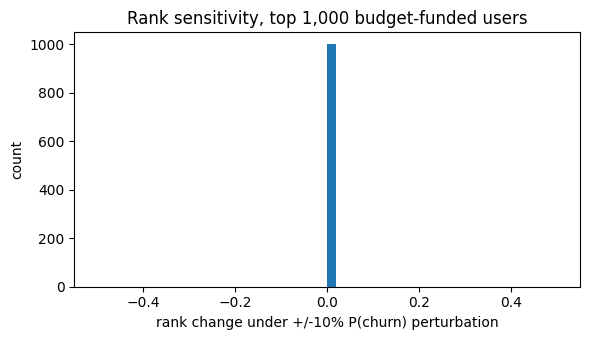

In [9]:
results_sens, sens_summary = rank_sensitivity(results, n_interventions)

print(f"Among the top {n_interventions:,} budget-funded users:")
print(f"  median rank_delta under +/-10% P(churn) perturbation: {sens_summary['median_rank_delta']:.0f}")
print(f"  users with rank_delta > {n_interventions} (could fall out of budget): "
      f"{sens_summary['n_borderline']} ({sens_summary['pct_borderline']:.1f}%)")
print(f"  distinct p_churn_raw values among top {n_interventions:,}: {sens_summary['n_distinct_p_churn_raw_top_k']} "
      f"(largest tie group: {sens_summary['largest_tie_group_top_k']})")

top_k = results_sens.iloc[:n_interventions]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(top_k["rank_delta"], bins=50)
ax.set_xlabel("rank change under +/-10% P(churn) perturbation")
ax.set_ylabel("count")
ax.set_title(f"Rank sensitivity, top {n_interventions:,} budget-funded users")
fig.tight_layout()

results.to_csv(os.path.join(RESULTS_DIR, "retention_priority_scores.csv"), index=False)

**Caveat on this "0% borderline" result — the tie structure is still concentrated, and it explains the churn-only strategy's collapse above.** Isotonic regression fits a piecewise-*constant* monotone map (280 distinct output values across 241,526 test users). The churn model is confident enough that the top of the ranking is dominated by one large tie group: among the top 1,000 budget-funded users, only **23** distinct `p_churn` values occur, and the largest tie group alone has **903** of those 1,000 users. A uniform ±10% multiplicative perturbation can't reorder users who already share a score, so the "0 rank movement" here is almost entirely a tie-structure artifact, not genuine model confidence.

This directly explains why **churn-probability-only ranking collapsed to ~20 TWD** in the budget-allocation comparison above: once 903 of the top 1,000 users share the same `p_churn`, sorting by `p_churn` alone has almost nothing left to break ties with, so it effectively picks an arbitrary subset of that tied group — which happens to include users with near-zero `e_fwd_rev`. The combined model ranking doesn't have this failure mode because `e_fwd_rev` still fully differentiates within the tied group, which is exactly the reason the priority-score formula multiplies the two signals together rather than using `p_churn` alone. The underlying limitation is the same regardless of model: isotonic regression buys excellent ECE at the cost of losing fine-grained probability resolution, which matters for ranking even though it doesn't matter for the calibration metric itself. A finer non-parametric method (e.g. isotonic regression with more bins forced, or Platt/logistic scaling with an intercept term) would preserve ECE quality while giving less-tied probabilities for ranking — a natural follow-up, not implemented here.